# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42897 sha256=2f1bb8a68af3149ee5f0afeab105575719862062614253387b84d50d95146534
  Stored in directory: /root/.cache/pip/wheels/e9/a6/9e/a5cead15269b79ab7ebf051cfc3f7adcbd5a880e683e94736a
Successfully built assertpy


In [3]:
!tar -xvf /content/waf-urls.tar.xz -C /content/

waf-urls.csv


## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [5]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded = start_symbol * (n - 1) + text + end_symbol * n
    return (padded[i:i+n] for i in range(len(padded) - n + 1))

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [6]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1

    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 13134.56it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 80350.65it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [7]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))

    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)

            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] = co_matrix.get((idx, prev_idx), 0) + 1
                co_matrix[prev_idx, idx] = co_matrix.get((prev_idx, idx), 0) + 1

            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i, 0] > 0:
            co_matrix[i, j] = co_matrix[i, j] / row_sums[i, 0]

    return co_matrix

In [8]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:02<00:00, 16878.88it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 1745320.56it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [06:34<00:00, 92.13it/s] 


Normalizing...


100%|██████████| 2542234/2542234 [01:08<00:00, 36859.91it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [9]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [24]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = url[:padded_len].ljust(padded_len, pad_symbol)

        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [23]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [22]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_weights, dtype=torch.float32),
            freeze=True
        )

        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)

        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)

        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = torch.flatten(x, start_dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(1)

In [26]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [27]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [28]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.7121, Val Acc=0.8727
Epoch 2: Train Acc=0.8822, Val Acc=0.8783
Epoch 3: Train Acc=0.9014, Val Acc=0.9097
Epoch 4: Train Acc=0.9110, Val Acc=0.9199
Epoch 5: Train Acc=0.9198, Val Acc=0.9234
Epoch 6: Train Acc=0.9228, Val Acc=0.9279
Epoch 7: Train Acc=0.9267, Val Acc=0.9294
Epoch 8: Train Acc=0.9290, Val Acc=0.9330
Epoch 9: Train Acc=0.9320, Val Acc=0.9372
Epoch 10: Train Acc=0.9338, Val Acc=0.9235


## 6. Evaluation

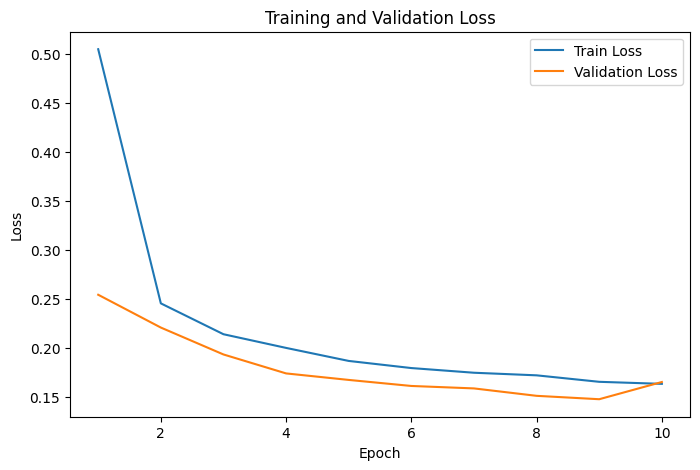

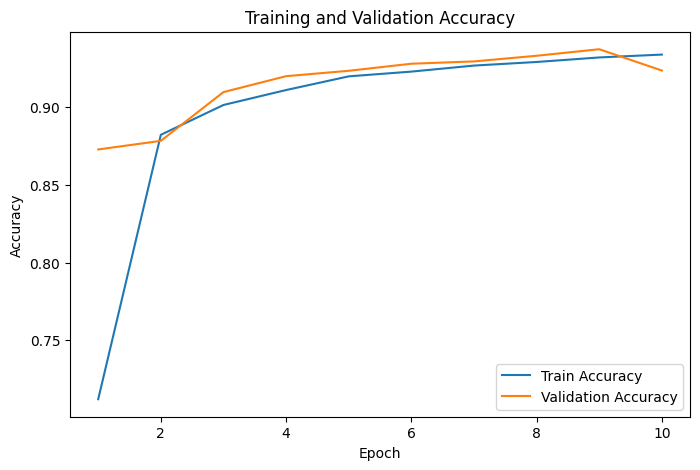

In [29]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
epochs = range(1, len(history['loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['acc'], label='Train Accuracy')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader
import torch
import numpy as np

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report

X_test = transform_urls(urls_test.tolist(), MAX_URL_LEN, N, n2i_urls)
y_test_np = np.array(labels_test)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test_np, dtype=torch.float32)
)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        pred = (out > 0.5).int().cpu().numpy().reshape(-1)

        y_true.extend(y.numpy().astype(int))
        y_pred.extend(pred.astype(int))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
[[6349  794]
 [ 182 4785]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9721    0.8888    0.9286      7143
           1     0.8577    0.9634    0.9075      4967

    accuracy                         0.9194     12110
   macro avg     0.9149    0.9261    0.9180     12110
weighted avg     0.9252    0.9194    0.9199     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:**
Lower loss generally indicates that the model’s predicted probabilities are closer to the true labels, which often correlates with higher accuracy. However, lower loss does not always guarantee higher accuracy because loss measures confidence while accuracy only measures whether predictions are correct. For example, a model may have lower loss by producing better-calibrated probabilities without changing the number of correct classifications. Therefore, loss and accuracy are related but not strictly proportional metrics.


**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**
A very large co-occurrence window size such as 50 is usually not ideal because it introduces many weak or noisy relationships between distant n-grams, which can reduce the quality of the learned embeddings and increase computational cost. Smaller window sizes typically capture more meaningful local structural patterns in URLs. Other compression or embedding methods include PCA, autoencoders, word2vec-style skip-gram models, or hashing-based feature compression, which can reduce dimensionality while preserving important semantic relationships.


## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`